# Demonstration of rotationally symmetric SVD decomposition in Panther-EM.

1. Download and simulate cryo-EM projections of a structure
2. Perform optimized SVD decomposition by exploiting in-plane rotational symmetry (in polar coordinates)
3. Plot singular values of the decomposition
4. Plot polar/cartesian features of decomposition

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch_so3 import get_uniform_euler_angles
from ttsim3d.models import Simulator, SimulatorConfig

from panther_em.decomposition import PolarProjectionDecomposer
from panther_em.inference.projection_reconstruction import ProjectionReconstructor
from panther_em.inference.correlation import compute_correlogram

/home/mgiammar/git_repositories/Panther-EM/.venv/lib/python3.13/site-packages/cupy/_environment.py:596: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


## Load in volume to take projections from

In [2]:
!wget -nc https://files.rcsb.org/download/pdb_00001dpo.cif

File ‘pdb_00001dpo.cif’ already there; not retrieving.



In [3]:
pdb_path = "pdb_00001dpo.cif"

In [4]:
# Instantiate the configuration object
sim_conf = SimulatorConfig(
    voltage=300.0,  # in keV
    apply_dose_weighting=True,
    dose_start=0.0,  # in e-/A^2
    dose_end=15.0,  # in e-/A^2
    upsampling=-1,  # auto
)

# Instantiate the simulator
sim = Simulator(
    pdb_filepath=pdb_path,
    pixel_spacing=0.4,  # Angstroms
    volume_shape=(256, 256, 256),
    b_factor_scaling=1.0,
    additional_b_factor=30.0,
    simulator_config=sim_conf,
)

In [5]:
# Run the simulation
volume = sim.run()
print(type(volume))
print(volume.shape)

<class 'torch.Tensor'>
torch.Size([256, 256, 256])


In [6]:
# import mrcfile

# # NOTE: Or load in pre-computed volume from elsewhere
# volume_path = "/data/mgiammar/MOSAICS/data/volumes/parsed_6Q8Y_whole_LSU_match3.mrc"
# volume = mrcfile.read(volume_path).data.copy()
# volume = torch.from_numpy(volume).float()
# print(type(volume))
# print(volume.shape)

In [7]:
volume = volume.numpy()

Text(0.5, 1.0, 'Projection along z-axis')

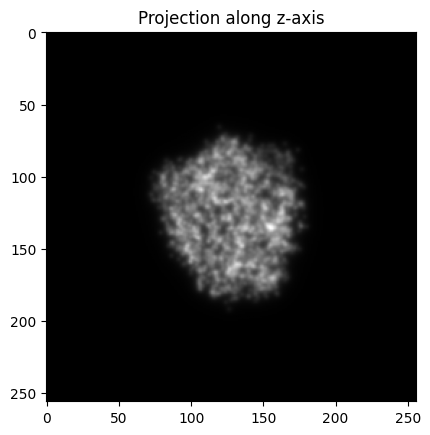

In [8]:
plt.imshow(volume.sum(axis=0), cmap="gray")
plt.title("Projection along z-axis")

## Define the out-of-plane orientations

Using `torch-so3` to approximate points over SO(3) space, except all in-plane angles are set to zero.

In [9]:
angles = get_uniform_euler_angles(psi_step=360.0, theta_step=6.0)
print(angles.shape)

phi_angles = angles[:, 0].numpy()
theta_angles = angles[:, 1].numpy()

torch.Size([1148, 3])


## Run the decomposition

In [19]:
radial_components = 256
angular_components = 360

k_max = 240
eig_max = 128

decomposer = PolarProjectionDecomposer(
    volume=volume,
    phi_values=phi_angles,
    theta_values=theta_angles,
    num_radius=radial_components,
    num_angle=angular_components,
    device="cuda",
)

result = decomposer.do_decomposition(k_max=k_max, eig_max=eig_max)

decomp freq blocks: 100%|██████████| 30/30 [00:02<00:00, 10.54it/s]


In [20]:
result

DecompositionResult(
    k_max=240,
    eig_max=128,
    num_fourier_filters=1,
    num_orientations=1148,
    num_angular_components=360,
    num_radial_components=256,
    created_at='2026-04-09T13:49:17.426599'
)

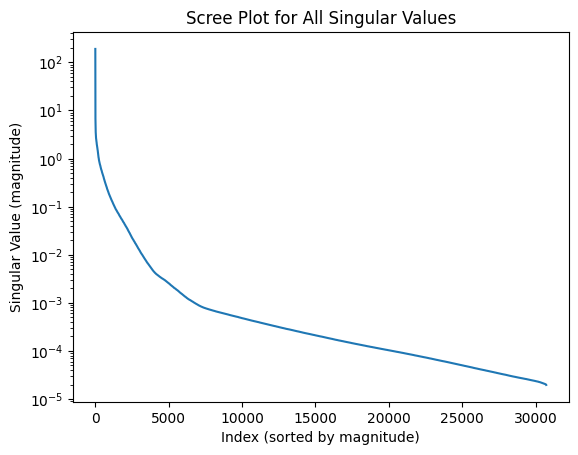

In [21]:
fix, ax = result.scree_plot()
plt.yscale("log")

## Visualize real/imag feature components in polar and cartesian space

In [22]:
reconstructor = ProjectionReconstructor(
    result=result,
    image_shape=(volume.shape[-2], volume.shape[-1]),
    device="cuda",
)

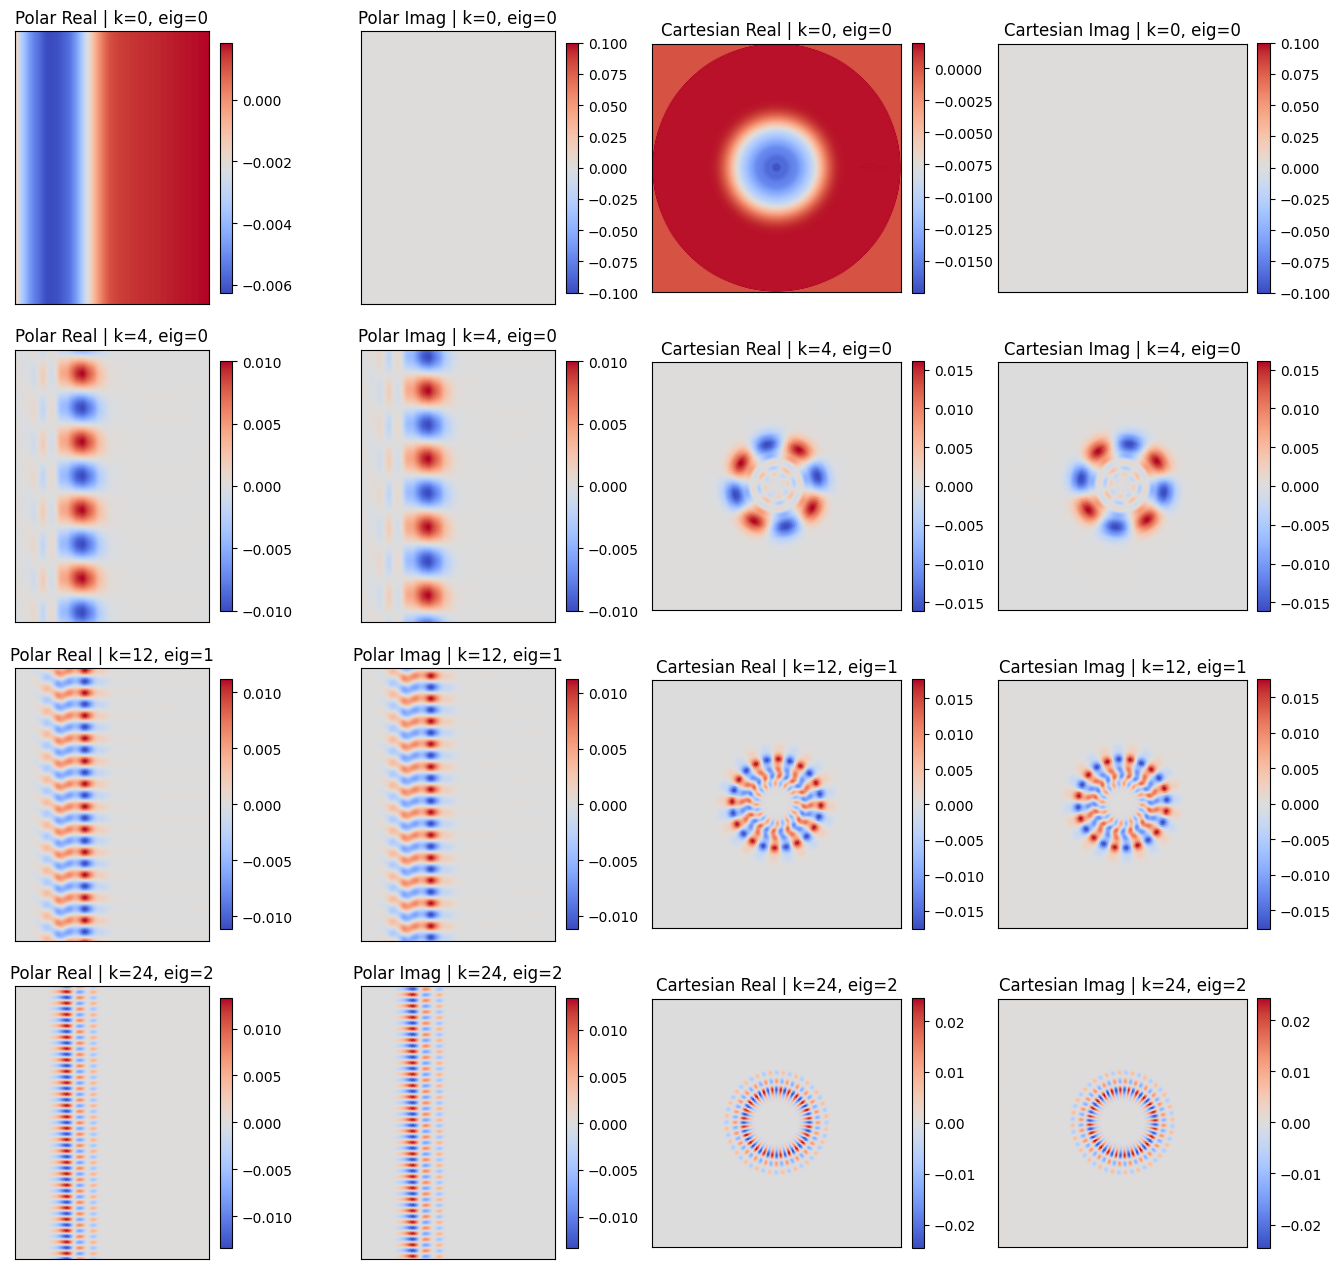

In [23]:
# Pick a few (k_idx, eig_idx) feature pairs to inspect
feature_pairs = [(0, 0), (4, 0), (12, 1), (24, 2)]

n = len(feature_pairs)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n), squeeze=False)

for row, (k_idx, eig_idx) in enumerate(feature_pairs):
    polar_feature = reconstructor.construct_polar_feature(k_idx=k_idx, eig_idx=eig_idx)
    cart_feature = reconstructor.construct_cartesian_feature(
        k_idx=k_idx, eig_idx=eig_idx
    )

    panels = [
        (np.real(polar_feature), "Polar Real"),
        (np.imag(polar_feature), "Polar Imag"),
        (np.real(cart_feature), "Cartesian Real"),
        (np.imag(cart_feature), "Cartesian Imag"),
    ]

    for col, (img, title) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(img, cmap="coolwarm")
        ax.set_title(f"{title} | k={k_idx}, eig={eig_idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Projection reconstructions up to a certain rank

In [24]:
reconstructor = ProjectionReconstructor(
    result=result,
    image_shape=(volume.shape[-2], volume.shape[-1]),
    device="cuda",
)

In [26]:
# ranks = [4, 32, 128, 256]
ranks = [4, 32, 128]
reconstructions = []

for r in ranks:
    recon = reconstructor.reconstruct_projection(
        orientation_idx=0,
        fourier_filter_idx=0,
        num_components=r,
        return_polar=False,
        return_torch=False,
    )
    reconstructions.append(recon)

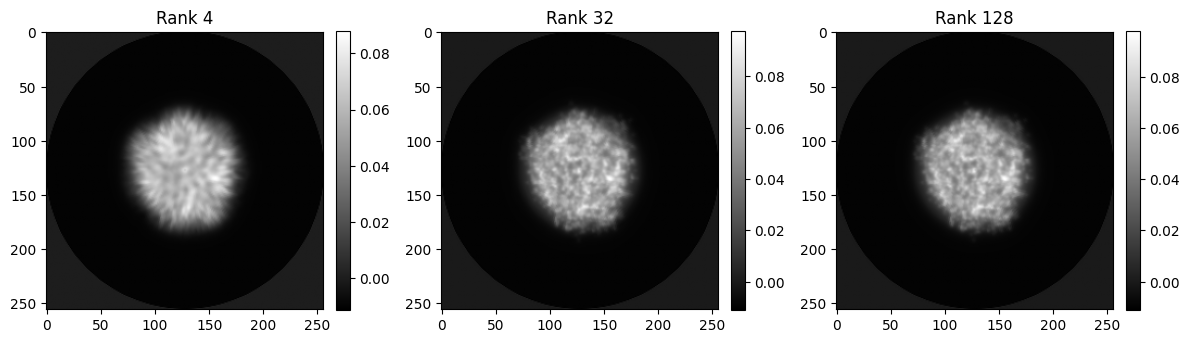

In [27]:
# Plot the reconstructions
fig, axes = plt.subplots(1, len(ranks), figsize=(4 * len(ranks), 4))

for ax, recon, r in zip(axes, reconstructions, ranks):
    im = ax.imshow(recon.real, cmap="gray")
    ax.set_title(f"Rank {r}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [28]:
print("left-singular-vectors shape:                  ", result.U.shape)
print("singular-values shape:                        ", result.S.shape)
print("right-singular-vectors (conj transpose) shape:", result.Vh.shape)

left-singular-vectors shape:                   (1, 1148, 240, 128)
singular-values shape:                         (240, 128)
right-singular-vectors (conj transpose) shape: (240, 128, 256)
